In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
# Display all columns
pd.set_option("display.max_columns", None)

In [2]:
movies = pd.read_csv("movies_updated.csv")

# movies.head()

In [3]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       4000 non-null   object 
 1   rating     3960 non-null   object 
 2   genre      4000 non-null   object 
 3   year       4000 non-null   int64  
 4   released   4000 non-null   object 
 5   score      4000 non-null   float64
 6   votes      4000 non-null   int64  
 7   director   4000 non-null   object 
 8   writer     3999 non-null   object 
 9   star       3999 non-null   object 
 10  country    4000 non-null   object 
 11  budget     4000 non-null   int64  
 12  gross      3831 non-null   float64
 13  company    3990 non-null   object 
 14  runtime,,  4000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 468.9+ KB


In [4]:
movies.shape

(4000, 15)

In [5]:
movies.describe

<bound method NDFrame.describe of                                                 name rating      genre  year  \
0                                        The Shining      R      Drama  1980   
1                                    The Blue Lagoon      R  Adventure  1980   
2     Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   
3                                          Airplane!     PG     Comedy  1980   
4                                         Caddyshack      R     Comedy  1980   
...                                              ...    ...        ...   ...   
3995                                   Birthday Girl      R     Comedy  2001   
3996                                    Human Nature      R     Comedy  2001   
3997                                            Made      R     Comedy  2001   
3998                           One Night at McCool's      R     Comedy  2001   
3999                                  Dr. Dolittle 2     PG     Comedy  2001   

     

In [6]:
movies.columns

Index(['name', 'rating', 'genre', 'year', 'released', 'score', 'votes',
       'director', 'writer', 'star', 'country', 'budget', 'gross', 'company',
       'runtime,,'],
      dtype='object')

In [7]:
movies.isnull()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
movies.isnull().sum().sum()

np.int64(221)

In [9]:
movies.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3995    False
3996    False
3997    False
3998    False
3999    False
Length: 4000, dtype: bool

In [10]:
movies.dtypes

name          object
rating        object
genre         object
year           int64
released      object
score        float64
votes          int64
director      object
writer        object
star          object
country       object
budget         int64
gross        float64
company       object
runtime,,     object
dtype: object

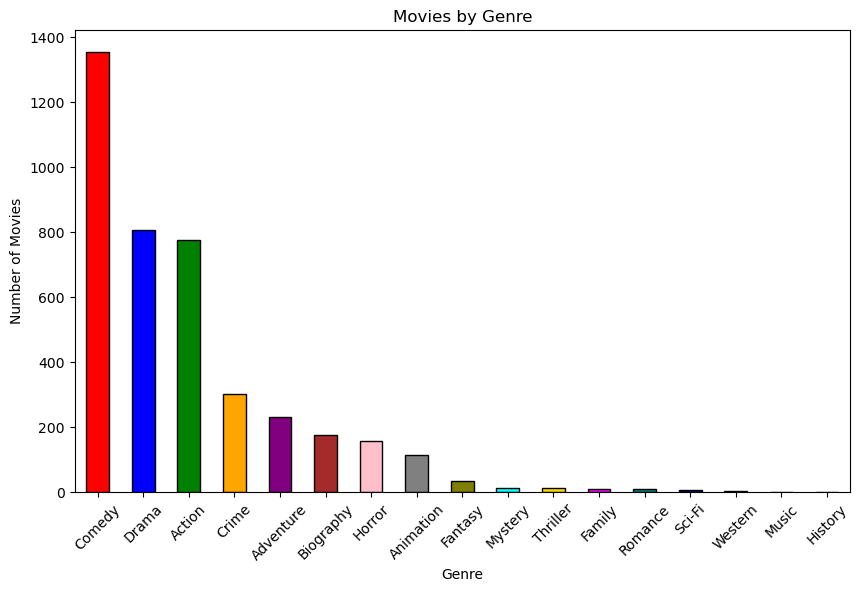

In [11]:
# Visualization Movies By Genre
colors = [
    "red", "blue", "green", "orange", "purple",
    "brown", "pink", "gray", "olive", "cyan",
    "gold", "magenta", "teal", "navy"
]

movies["genre"].value_counts().plot(
    kind="bar",
    figsize=(10,6),
    color=colors,
    edgecolor="black",
    
    
)

plt.title("Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
# plt.legend(title="Genre")
plt.xticks(rotation=45)
plt.show()

In [12]:
# Highest Rated Movies
movies.nlargest(10, "score")[
    ["name","genre","score"]
]

,name,genre,score
2443,The Shawshank Redemption,Drama,9.3
2247,Schindler's List,Biography,8.9
2444,Pulp Fiction,Crime,8.9
2445,Forrest Gump,Drama,8.8
3444,Fight Club,Drama,8.8
3845,The Lord of the Rings: The Fellowship of the Ring,Action,8.8
2,Star Wars: Episode V - The Empire Strikes Back,Action,8.7
1643,Goodfellas,Biography,8.7
3443,The Matrix,Action,8.7
1845,The Silence of the Lambs,Crime,8.6


In [13]:
# Top 10 Gross Movies
movies.nlargest(10, "gross")[
    ["name","gross"]
]

,name,gross
3045,Titanic,2.201647e+09
2448,The Lion King,1.083721e+09
2245,Jurassic Park,1.033928e+09
3451,Star Wars: Episode I - The Phantom Menace,1.027083e+09
3843,Harry Potter and the Sorcerer's Stone,1.006968e+09
3845,The Lord of the Rings: The Fellowship of the Ring,8.976901e+08
2844,Independence Day,8.174009e+08
209,E.T. the Extra-Terrestrial,7.929106e+08
2445,Forrest Gump,6.782261e+08
3453,The Sixth Sense,6.728063e+08


In [14]:
movies_clean = movies.copy()
# movies_clean.head()

In [15]:
# check if there is missing value
movies_clean.isnull().sum().sort_values(ascending=False)

gross        169
rating        40
company       10
star           1
writer         1
name           0
genre          0
votes          0
score          0
released       0
year           0
country        0
director       0
budget         0
runtime,,      0
dtype: int64

In [16]:
# Missing Value Percentage
missing = movies_clean.isnull().sum()

missing_percentage = (
    missing / len(movies_clean)
) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage":  missing_percentage
})

missing_df.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
gross,169,4.225
rating,40,1.000
company,10,0.250
star,1,0.025
writer,1,0.025
name,0,0.000
genre,0,0.000
votes,0,0.000
score,0,0.000
released,0,0.000


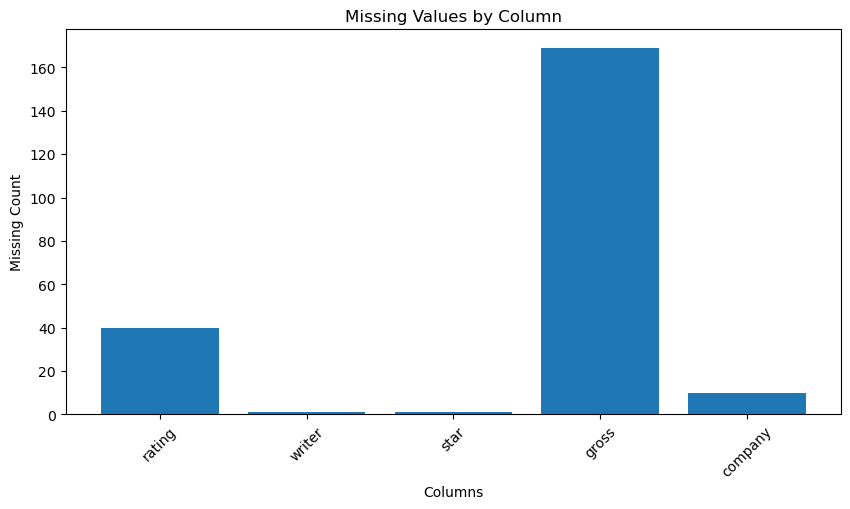

In [17]:
# Step 4: Visualize Missing Values

missing_df = missing_df[missing_df["Missing Values"] > 0]

plt.figure(figsize=(10,5))

plt.bar(
    missing_df.index,
    missing_df["Missing Values"],
    
)

plt.xticks(rotation=45)

plt.title("Missing Values by Column")

plt.xlabel("Columns")

plt.ylabel("Missing Count")

plt.show()

In [18]:
movies_clean.duplicated().sum()

np.int64(0)

In [19]:
movies_clean = movies_clean.drop_duplicates()

In [20]:
movies_clean.dtypes

name          object
rating        object
genre         object
year           int64
released      object
score        float64
votes          int64
director      object
writer        object
star          object
country       object
budget         int64
gross        float64
company       object
runtime,,     object
dtype: object

In [21]:
# Convert Released Date
movies_clean = movies.copy()

movies_clean["released"] = (
    movies_clean["released"]
    .str.split("(")
    .str[0]
)

movies_clean["released"] = pd.to_datetime(
    movies_clean["released"],
    errors="coerce"
)

movies_clean["released"]

0      1980-06-13
1      1980-07-02
2      1980-06-20
3      1980-07-02
4      1980-07-25
          ...    
3995   2002-02-01
3996   2001-09-12
3997   2001-08-31
3998   2001-04-27
3999   2001-06-22
Name: released, Length: 4000, dtype: datetime64[ns]

In [22]:
# Extract Features
# 1. Months
movies_clean["release_month"] = (
    movies_clean["released"]
    .dt.month_name()
)
# 2.Year
movies_clean["release_year"] = (
    movies_clean["released"]
    .dt.year
)
# 3.Day
movies_clean["release_day"] = (
    movies_clean["released"]
    .dt.day_name()
)
# 4.Quarter
movies_clean["release_quarter"] = (
    movies_clean["released"]
    .dt.quarter
)

In [23]:
# Check Budget and Gross
movies_clean[["budget","gross"]].describe()

,budget,gross
count,4.000000e+03,3.831000e+03
mean,1.542740e+07,4.172202e+07
std,2.248639e+07,9.259504e+07
min,0.000000e+00,3.090000e+02
25%,0.000000e+00,2.835743e+06
50%,7.000000e+06,1.183822e+07
75%,2.100000e+07,3.560495e+07
max,2.000000e+08,2.201647e+09


In [24]:
# Highest Budget Movies
movies_clean.nlargest(
    10,
    "budget"
)[
    ["name","budget"]
]

,name,budget
3045,Titanic,200000000
2665,Waterworld,175000000
3479,Wild Wild West,170000000
3086,Speed 2: Cruise Control,160000000
3485,The 13th Warrior,160000000
3248,Armageddon,140000000
3299,Lethal Weapon 4,140000000
3652,The Perfect Storm,140000000
3858,Pearl Harbor,140000000
3965,Final Fantasy: The Spirits Within,137000000


In [25]:
# Highest Gross Movies
movies_clean.nlargest(
    10,
    "gross"
)[
    ["name","budget"]
]

,name,budget
3045,Titanic,200000000
2448,The Lion King,45000000
2245,Jurassic Park,63000000
3451,Star Wars: Episode I - The Phantom Menace,115000000
3843,Harry Potter and the Sorcerer's Stone,125000000
3845,The Lord of the Rings: The Fellowship of the Ring,93000000
2844,Independence Day,75000000
209,E.T. the Extra-Terrestrial,10500000
2445,Forrest Gump,55000000
3453,The Sixth Sense,40000000


In [26]:
df = movies_clean.copy()
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,",release_month,release_year,release_day,release_quarter
0,The Shining,R,Drama,1980,1980-06-13,8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,",June,1980.0,Friday,2.0
1,The Blue Lagoon,R,Adventure,1980,1980-07-02,5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,",July,1980.0,Wednesday,3.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,1980-06-20,8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,"124.0,",June,1980.0,Friday,2.0
3,Airplane!,PG,Comedy,1980,1980-07-02,7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,"88.0,",July,1980.0,Wednesday,3.0
4,Caddyshack,R,Comedy,1980,1980-07-25,7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,"98.0,",July,1980.0,Friday,3.0


In [27]:
# 1. Movies by Genre (Most Important)

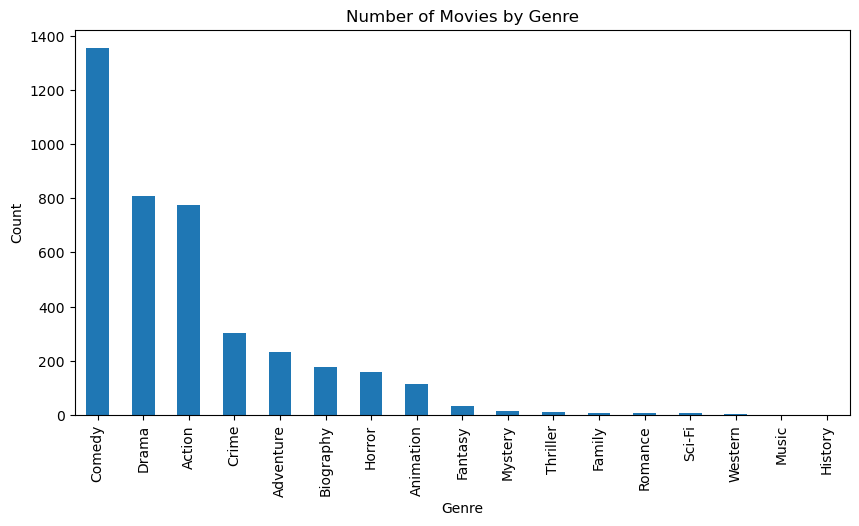

In [28]:
genre_counts = df["genre"].value_counts()

genre_counts.plot(
    kind="bar",
    figsize=(10,5),
    title="Number of Movies by Genre"
)
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

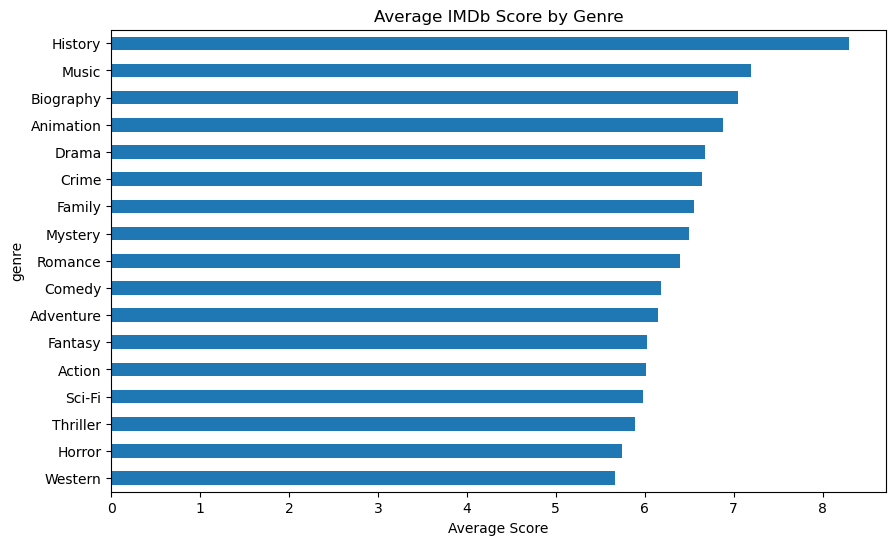

In [29]:
# Average score by genre
avg_score_genre = df.groupby("genre")["score"].mean().sort_values()

avg_score_genre.plot(
    kind="barh",
    figsize=(10,6),
    title="Average IMDb Score by Genre"
)
plt.xlabel("Average Score")
plt.show()

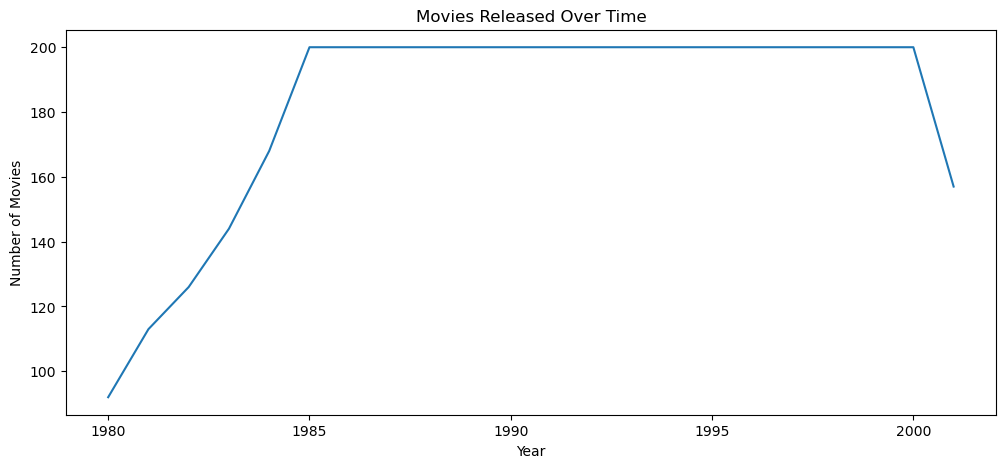

In [30]:
# Movies Released per Year (Trend)
movies_per_year = df["year"].value_counts().sort_index()

movies_per_year.plot(
    kind="line",
    figsize=(12,5),
    title="Movies Released Over Time"
)
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

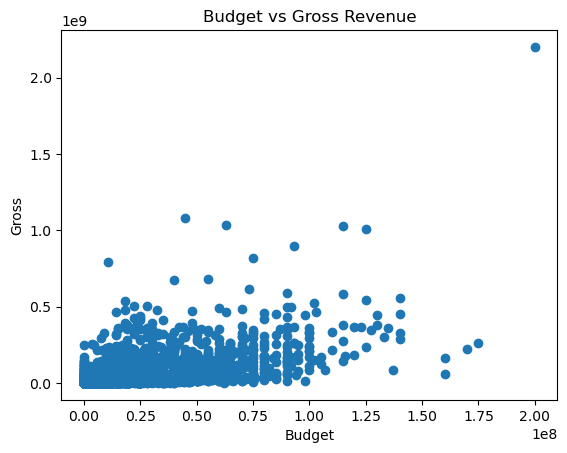

In [31]:
# Budget vs Gross (Profit Analysis)
plt.scatter(df["budget"], df["gross"])

plt.title("Budget vs Gross Revenue")
plt.xlabel("Budget")
plt.ylabel("Gross")

plt.show()

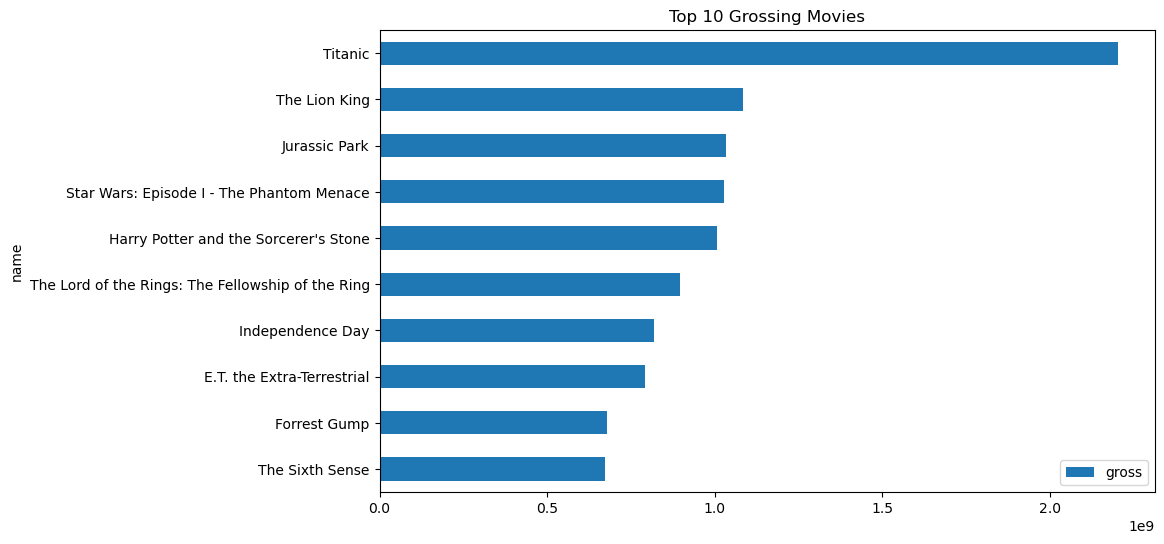

In [32]:
# Top 10 Highest Gross Movies
top_gross = df.nlargest(10, "gross")[["name", "gross"]]

top_gross.plot(
    kind="barh",
    x="name",
    y="gross",
    figsize=(10,6),
    title="Top 10 Grossing Movies"
)
plt.gca().invert_yaxis()
plt.show()

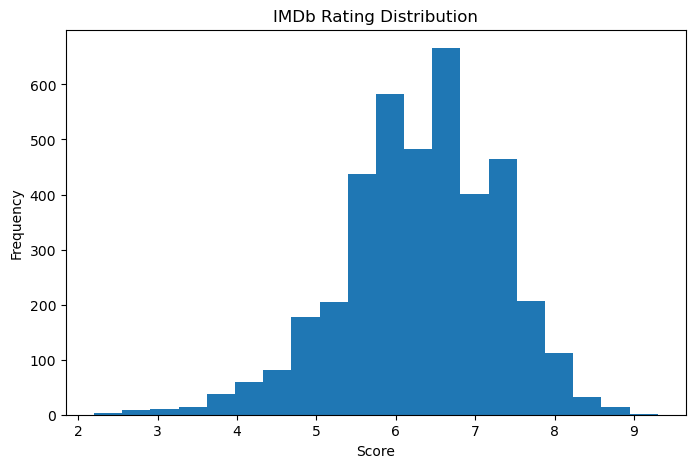

In [33]:
# Rating Distribution
df["score"].plot(
    kind="hist",
    bins=20,
    figsize=(8,5),
    title="IMDb Rating Distribution"
)
plt.xlabel("Score")
plt.show()

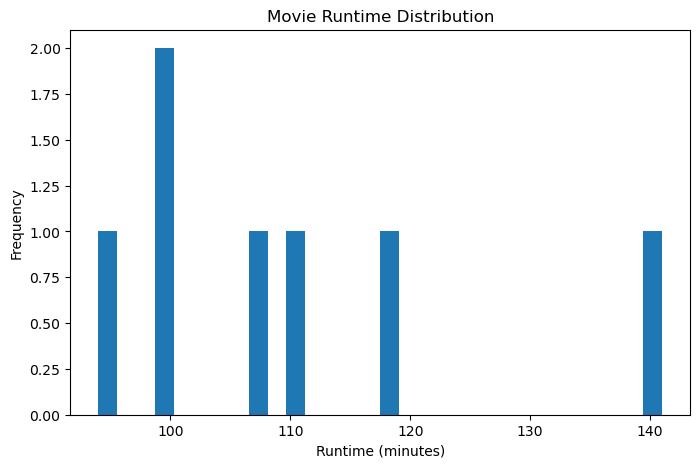

In [35]:
# Runtime Distribution
df.columns = df.columns.str.replace(",", "").str.strip()
# df.columns
df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce")
df["runtime"].plot(
    kind="hist",
    bins=30,
    figsize=(8,5),
    title="Movie Runtime Distribution"
)
plt.xlabel("Runtime (minutes)")
plt.show()

In [ ]:
# Top Directors (Most Movies)
top_directors = df["director"].value_counts().head(10)

top_directors.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Directors by Number of Movies"
)
plt.ylabel("Movies Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df[["score","votes","budget","gross","runtime"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Country Analysis
df["country"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="Top Movie Producing Countries"
)

plt.xticks(rotation=45)

plt.show()

In [42]:
import dash
from dash import dcc, html, Input, Output

app = dash.Dash(__name__)

app.layout = html.Div([

    html.H1("🎬 Movie Analytics Dashboard", style={"textAlign": "center"}),

    html.Div([

        dcc.Dropdown(
            id="genre_filter",
            options=[{"label": g, "value": g} for g in df["genre"].unique()],
            value=df["genre"].unique()[0],
            clearable=False
        )

    ], style={"width": "40%", "margin": "auto"}),

    dcc.Graph(id="genre_chart"),

    dcc.Graph(id="score_chart"),

])

# Movies by Genre Chart
@app.callback(
    Output("genre_chart", "figure"),
    Input("genre_filter", "value")
)
def update_genre(selected_genre):
    filtered = df[df["genre"] == selected_genre]
    fig = px.histogram(
        filtered,
        x="year",
        title=f"Movies in {selected_genre} over Years"
    )
    return fig

# Average Score Chart
@app.callback(
Output("score_chart", "figure"),
Input("genre_filter", "value")
)
def update_score(selected_genre):
    filtered = df[df["genre"] == selected_genre]
    avg = filtered.groupby("year")["score"].mean().reset_index()
    fig = px.line(
        avg,
        x="year",
        y="score",
        title=f"Average Score Trend - {selected_genre}"
    )
    return fig
# Run the App
if __name__ == "__main__":
    app.run(debug=True)